# Import Dependcies

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

/Users/alvislow/repos/DSA3101/DSA3101_group9/question_4
/Users/alvislow/repos/DSA3101/DSA3101_group9


In [9]:
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

In [ ]:
from utils import data_cleaning 
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.model_selection import cross_val_score

# Data Cleaning

In [11]:
full_path = os.path.join(parent_dir,  "data/bank_customers_train.csv")

df = pd.read_csv(full_path)
print(df.head())
print(len(df))
print(df.isnull().sum())


   age          job   marital          education default housing loan  \
0   35  blue-collar    single        high.school     NaN      no   no   
1   52  blue-collar   married                NaN     NaN     yes   no   
2   38     services   married        high.school     NaN      no   no   
3   44       admin.   married  university.degree      no     yes   no   
4   25     services  divorced           basic.4y      no     yes   no   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0   cellular   jul         thu  ...         3    999         0  nonexistent   
1  telephone   jun         thu  ...         4    999         0  nonexistent   
2  telephone   jun         tue  ...         2    999         0  nonexistent   
3  telephone   oct         wed  ...         1    999         0  nonexistent   
4  telephone   may         fri  ...         1    999         0  nonexistent   

  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed    y  
0        

In [3]:
colums_missing_values = ['housing', 'loan', 'marital', 'education', 'job']
df = data_cleaning.drop_missing_values(df, colums_missing_values)
print(df.isnull().sum())
print(df.shape)

age                  0
job                  0
marital              0
education            0
default           7354
housing              0
loan                 0
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64
(36381, 21)


In [4]:
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

Unique values in age:
[35 38 44 25 49 30 34 22 32 36 28 58 50 29 51 52 54 27 42 40 43 39 56 31
 69 75 45 81 33 41 26 53 47 48 46 37 73 21 59 55 72 23 63 60 57 83 74 85
 20 24 76 71 66 18 62 78 68 65 61 77 70 88 19 67 82 64 86 80 79 98 17 84
 94 95 87 91 89]

Unique values in job:
['blue-collar' 'services' 'admin.' 'technician' 'self-employed' 'retired'
 'unemployed' 'entrepreneur' 'management' 'housemaid' 'student']

Unique values in marital:
['single' 'married' 'divorced']

Unique values in education:
['high.school' 'university.degree' 'basic.4y' 'basic.6y' 'basic.9y'
 'professional.course' 'illiterate']

Unique values in default:
[nan 'no' 'yes']

Unique values in housing:
['no' 'yes']

Unique values in loan:
['no' 'yes']

Unique values in contact:
['cellular' 'telephone']

Unique values in month:
['jul' 'jun' 'oct' 'may' 'aug' 'sep' 'apr' 'nov' 'mar' 'dec']

Unique values in day_of_week:
['thu' 'tue' 'wed' 'fri' 'mon']

Unique values in duration:
[ 117  253  749 ... 1128 1970 2184]


# Feature Engineering

In [5]:
num_features = ['age', 'duration', 'campaign', 'pdays', 'previous']
df = data_cleaning.scale_features(df, num_features)


# Binning Age into categories
age_bins = [0, 18, 30, 40, 50, 60, 100]  # Added 0 as minimum
age_labels = [0, 1, 2, 3, 4, 5]  # Added 0 for <18 if needed

df['age_bin'] = pd.cut(df['age'], 
                      bins=age_bins, 
                      labels=age_labels,
                      include_lowest=True)

# Frequency Encoding for 'job'
job_freq = df['job'].value_counts(normalize=True)
df['job_freq'] = df['job'].map(job_freq)


In [6]:
binary_mappings = {
    'default': {'no': 0, 'yes': 1, np.nan: -1},
    'housing': {'no': 0, 'yes': 1},
    'poutcome': {'failure': 0, 'success': 1, 'nonexistent': -1},
    'loan': {'no': 0, 'yes': 1},
    'y': {'no': 0, 'yes': 1}
}

df = data_cleaning.encode_categorical(
        df,
        label_encode_cols=['marital'],
        one_hot_encode_cols=['job', 'contact', 'month', 'day_of_week'],
        ordinal_encode_cols={'education': ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree']},
        binary_encode_cols= binary_mappings
    )

In [7]:
df['pdays'] = df['pdays'].replace(999, np.nan)

In [8]:
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

Unique values in age:
[-0.47072165 -0.17865838  0.40546815 -1.44426589  0.89224027 -0.95749377
 -0.56807608 -1.73632915 -0.76278492 -0.37336723 -1.15220262  1.76843008
  0.98959469 -1.05484819  1.08694912  1.18430354  1.37901238 -1.24955704
  0.21075931  0.01605046  0.30811373 -0.08130396  1.57372123 -0.86013935
  2.83932873  3.42345527  0.50282258  4.00758181 -0.6654305   0.11340488
 -1.34691146  1.28165796  0.69753142  0.79488585  0.600177   -0.27601281
  3.22874642 -1.83368358  1.8657845   1.47636681  3.131392   -1.63897473
  2.25520219  1.96313892  1.67107565  4.20229066  3.32610085  4.3969995
 -1.931038   -1.54162031  3.52080969  3.03403758  2.54726546 -2.12574685
  2.15784777  3.71551854  2.74197431  2.44991104  2.06049335  3.61816412
  2.93668315  4.68906277 -2.02839242  2.64461989  4.10493623  2.35255662
  4.49435392  3.91022739  3.81287296  5.662607   -2.22310127  4.29964508
  5.27318931  5.37054373  4.59170835  4.98112604  4.78641719]

Unique values in marital:
[2 1 0]

Uniqu

In [9]:
risk_score = (
    df['default'].apply(lambda x: 1 if x == 'yes' else 0) + 
    df['housing'].apply(lambda x: 1 if x == 'yes' else 0) + 
    df['loan'].apply(lambda x: 1 if x == 'yes' else 0)
)

In [10]:
print(df.dtypes)
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

age                   float64
marital                 int64
education             float64
default                 int64
housing                 int64
loan                    int64
duration              float64
campaign              float64
pdays                 float64
previous              float64
poutcome                int64
emp.var.rate          float64
cons.price.idx        float64
cons.conf.idx         float64
euribor3m             float64
nr.employed           float64
y                       int64
age_bin              category
job_freq              float64
job_blue-collar          bool
job_entrepreneur         bool
job_housemaid            bool
job_management           bool
job_retired              bool
job_self-employed        bool
job_services             bool
job_student              bool
job_technician           bool
job_unemployed           bool
contact_telephone        bool
month_aug                bool
month_dec                bool
month_jul                bool
month_jun 

<Axes: >

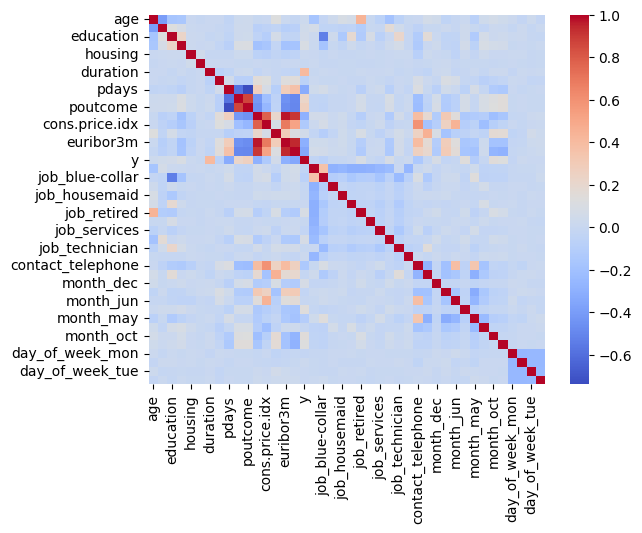

In [11]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

# Predicting Customer Conversion (Yes/No) - Classification

In [12]:
print(df.columns)
print(df['age_bin'].isnull().sum())

Index(['age', 'marital', 'education', 'default', 'housing', 'loan', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'age_bin', 'job_freq', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed'],
      dtype='object')
20285


## Logistic Regression

In [13]:
X = df.drop(columns=['y', 'default', 'pdays', 'age_bin'])  # Features
y = df['y']  # Target

# Train-Test Split
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Feature Scaling (Logistic Regression works better with normalized data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

param_dist = {
    'C': loguniform(0.001, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Randomized search
random_search = RandomizedSearchCV(LogisticRegression(), param_distributions=param_dist, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# Best model
print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

# Train Best Model on Full Training Data
best_model.fit(X_train, y_train)

# Predict
y_pred = best_model.predict(X_test)

# Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", scores.mean())


Best Parameters: {'C': np.float64(73.92266140516048), 'penalty': 'l1', 'solver': 'liblinear'}
Test Accuracy: 0.9075168338601072
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      6472
           1       0.63      0.41      0.49       805

    accuracy                           0.91      7277
   macro avg       0.78      0.69      0.72      7277
weighted avg       0.90      0.91      0.90      7277

Cross-Validation Accuracy: 0.9103444349469161


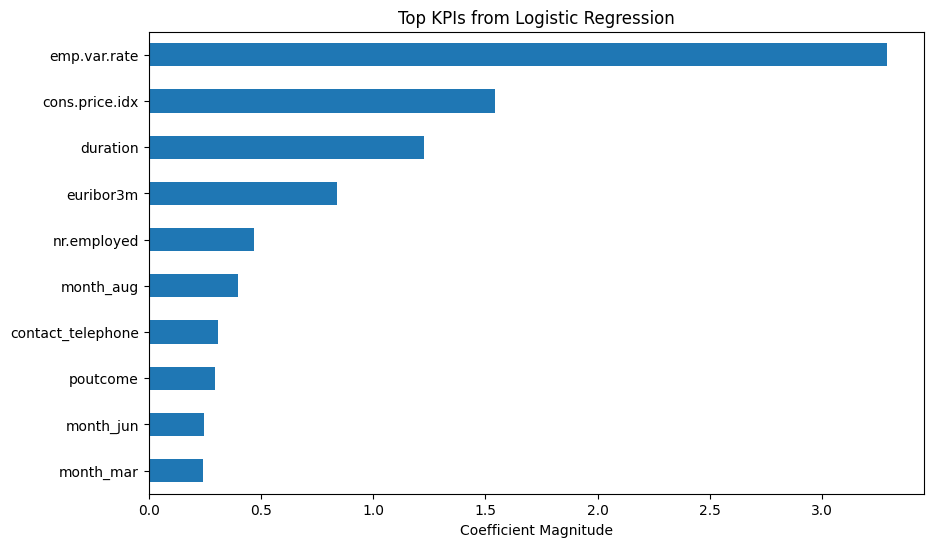

In [14]:
feature_importance = pd.Series(best_model.coef_[0], index=X.columns)

# Sort by importance
top_kpis = feature_importance.abs().sort_values(ascending=False).head(10)  # Top 10 most impactful features

# Plot top features
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
top_kpis.sort_values(ascending=True).plot(kind='barh')
plt.title("Top KPIs from Logistic Regression")
plt.xlabel("Coefficient Magnitude")
plt.show()

## Random Forest

In [15]:
# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [5, 10, 15, None],   # Tree depth (None means unlimited)
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],    # Minimum samples per leaf
    'class_weight': ['balanced', 'balanced_subsample'],  # Handle class imbalance
}

# Initialize base RandomForest model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Perform Randomized Search
random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=20, cv=5,
    scoring='roc_auc', n_jobs=-1, random_state=42
)
random_search.fit(X_train, y_train)

# Get the best model
best_rf = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

# Train with the best parameters
best_rf.fit(X_train, y_train)

# Predictions
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]  # Probability scores for ROC-AUC

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")

# Perform 5-Fold Cross-Validation
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {cv_scores.mean():.3f}")


Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15, 'class_weight': 'balanced_subsample'}
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.89      0.94      6472
           1       0.50      0.87      0.64       805

    accuracy                           0.89      7277
   macro avg       0.74      0.88      0.79      7277
weighted avg       0.93      0.89      0.90      7277

ROC-AUC Score: 0.946
Cross-Validation Accuracy: 0.888


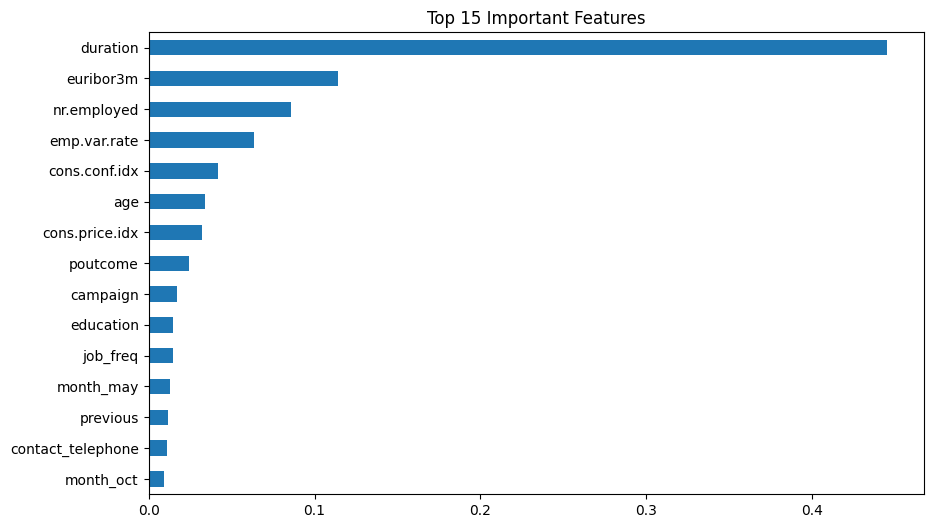

In [16]:
# Get feature importances
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
top_features.sort_values(ascending=True).plot(kind='barh')
plt.title('Top 15 Important Features')
plt.show()